<a href="https://colab.research.google.com/github/LuhOrange/WorkShop-2026.2/blob/main/MachineLearningRegressao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Os datasets são:
#### Ao escolher o dataset que você vai trabalhar, copie o path e cole na célula de abetura do arquivo para ter acesso ao dataframe.

*   **Real State Valuation Dataset** — Dataset de Taiwan sobre preços de imóveis, com colunas como distância até estação de metrô, número de lojas de conveniência próximas, latitude, longitude e idade do imóvel — todas numéricas, target também numérico (preço por área).
https://www.kaggle.com/datasets/quantbruce/real-estate-price-prediction

*   **Calculate Concrete Strength** — Dataset sobre resistência de concreto, com colunas como quantidade de cimento, água, agregados, idade da mistura — tudo numérico, prevendo a resistência à compressão (target numérico).
https://www.kaggle.com/datasets/prathamtripathi/regression-with-neural-networking



In [22]:
# Importar bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sklearn
warnings.filterwarnings('ignore')

# Bibliotecas de Machine Learning
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Configurar estilo para melhores visualizações
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Todas as bibliotecas importadas com sucesso!")
print("Versão do Scikit-learn:", sklearn.__version__)


Todas as bibliotecas importadas com sucesso!
Versão do Scikit-learn: 1.6.1


In [23]:
# Carregue seu dataset aqui
# Coloque o caminho do arquivo CSV que você baixou do Kaggle entre as aspas abaixo
df = pd.read_csv("concrete_data.csv")  # TODO: coloque o path do seu arquivo CSV aqui

# Separe suas features (X) e seu target (y)
# X = todas as colunas que serão usadas para prever (menos a coluna target)
# y = a coluna que você quer prever (deve ser numérica, já que é regressão)

X = df.drop(columns=['Strength'])  # TODO: coloque o nome da(s) coluna(s) que NÃO serão usadas como feature (ex: 'preco')
                                  # Strenght pois ele será o target, então não faz sentido manter como feature

y = df['Strength']  # TODO: coloque o nome da coluna que será o seu target (ex: 'preco')

print("Dataset carregado com sucesso!")
print(f"Formato do dataset: {X.shape}")
print(f"Número de amostras: {X.shape[0]}")
print(f"Número de features: {X.shape[1]}")
print(f"Faixa da variável target: {y.min():.2f} - {y.max():.2f}")
print(f"Valor médio do target: {y.mean():.2f}")

Dataset carregado com sucesso!
Formato do dataset: (1030, 8)
Número de amostras: 1030
Número de features: 8
Faixa da variável target: 2.33 - 82.60
Valor médio do target: 35.82


In [24]:
# Exibir informações básicas sobre nosso dataset
print("=== VISÃO GERAL DO DATASET ===")
print(f"Formato do dataset: {X.shape}")
print(f"Formato do target: {y.shape}")
print("\n=== PRIMEIRAS 5 LINHAS ===")
print(X.head())


=== VISÃO GERAL DO DATASET ===
Formato do dataset: (1030, 8)
Formato do target: (1030,)

=== PRIMEIRAS 5 LINHAS ===
   Cement  Blast Furnace Slag  Fly Ash  Water  Superplasticizer  \
0   540.0                 0.0      0.0  162.0               2.5   
1   540.0                 0.0      0.0  162.0               2.5   
2   332.5               142.5      0.0  228.0               0.0   
3   332.5               142.5      0.0  228.0               0.0   
4   198.6               132.4      0.0  192.0               0.0   

   Coarse Aggregate  Fine Aggregate  Age  
0            1040.0           676.0   28  
1            1055.0           676.0   28  
2             932.0           594.0  270  
3             932.0           594.0  365  
4             978.4           825.5  360  


In [25]:
print("\n=== RESUMO ESTATÍSTICO ===")
X.describe()


=== RESUMO ESTATÍSTICO ===


,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000


In [26]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cement              1030 non-null   float64
 1   Blast Furnace Slag  1030 non-null   float64
 2   Fly Ash             1030 non-null   float64
 3   Water               1030 non-null   float64
 4   Superplasticizer    1030 non-null   float64
 5   Coarse Aggregate    1030 non-null   float64
 6   Fine Aggregate      1030 non-null   float64
 7   Age                 1030 non-null   int64  
dtypes: float64(7), int64(1)
memory usage: 64.5 KB


In [27]:
print(f"\nValores ausentes nas features: ", X.isnull().sum().sum())
print(f"Valores ausentes no target: {pd.isnull(y).sum()}")


Valores ausentes nas features:  0
Valores ausentes no target: 0


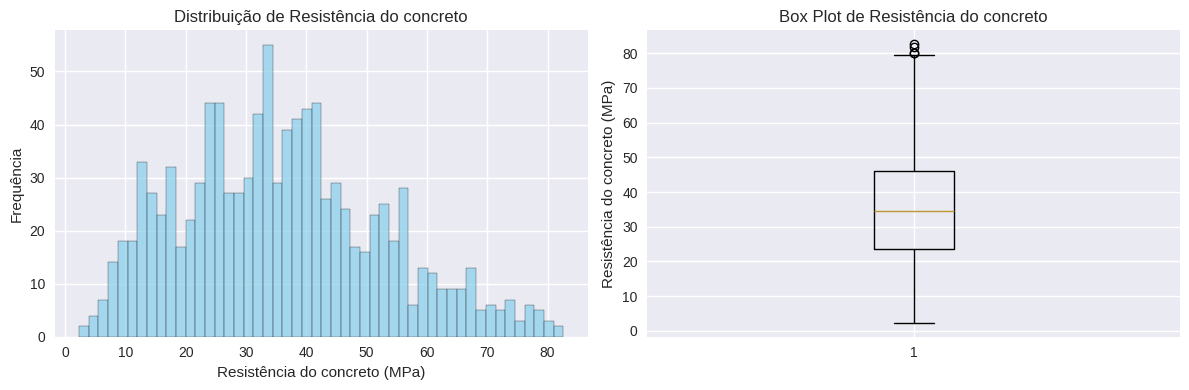

Estatísticas da variável target:
Média: 35.82 MPa
Mediana: 34.45 MPa
Desvio padrão: 16.71 MPa


In [28]:
# Definindo nome e unidade do target
nome_target = "Resistência do concreto"
unidade_target = "MPa"

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(y, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.title(f'Distribuição de {nome_target}')
plt.xlabel(f'{nome_target} ({unidade_target})' if unidade_target else nome_target)
plt.ylabel('Frequência')

plt.subplot(1, 2, 2)
plt.boxplot(y, vert=True)
plt.title(f'Box Plot de {nome_target}')
plt.ylabel(f'{nome_target} ({unidade_target})' if unidade_target else nome_target)

plt.tight_layout()
plt.show()

print(f"Estatísticas da variável target:")
print(f"Média: {y.mean():.2f} {unidade_target}")
print(f"Mediana: {np.median(y):.2f} {unidade_target}")
print(f"Desvio padrão: {y.std():.2f} {unidade_target}")

=== FEATURES (X) ===
Formato das features: (1030, 8)
Nomes das features: ['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer', 'Coarse Aggregate', 'Fine Aggregate', 'Age']
Tipos das features: [dtype('float64') dtype('int64')]

=== TARGET (y) ===
Formato do target: (1030,)
Tipo do target: <class 'pandas.core.series.Series'>
Target é o que queremos prever: Preços das casas


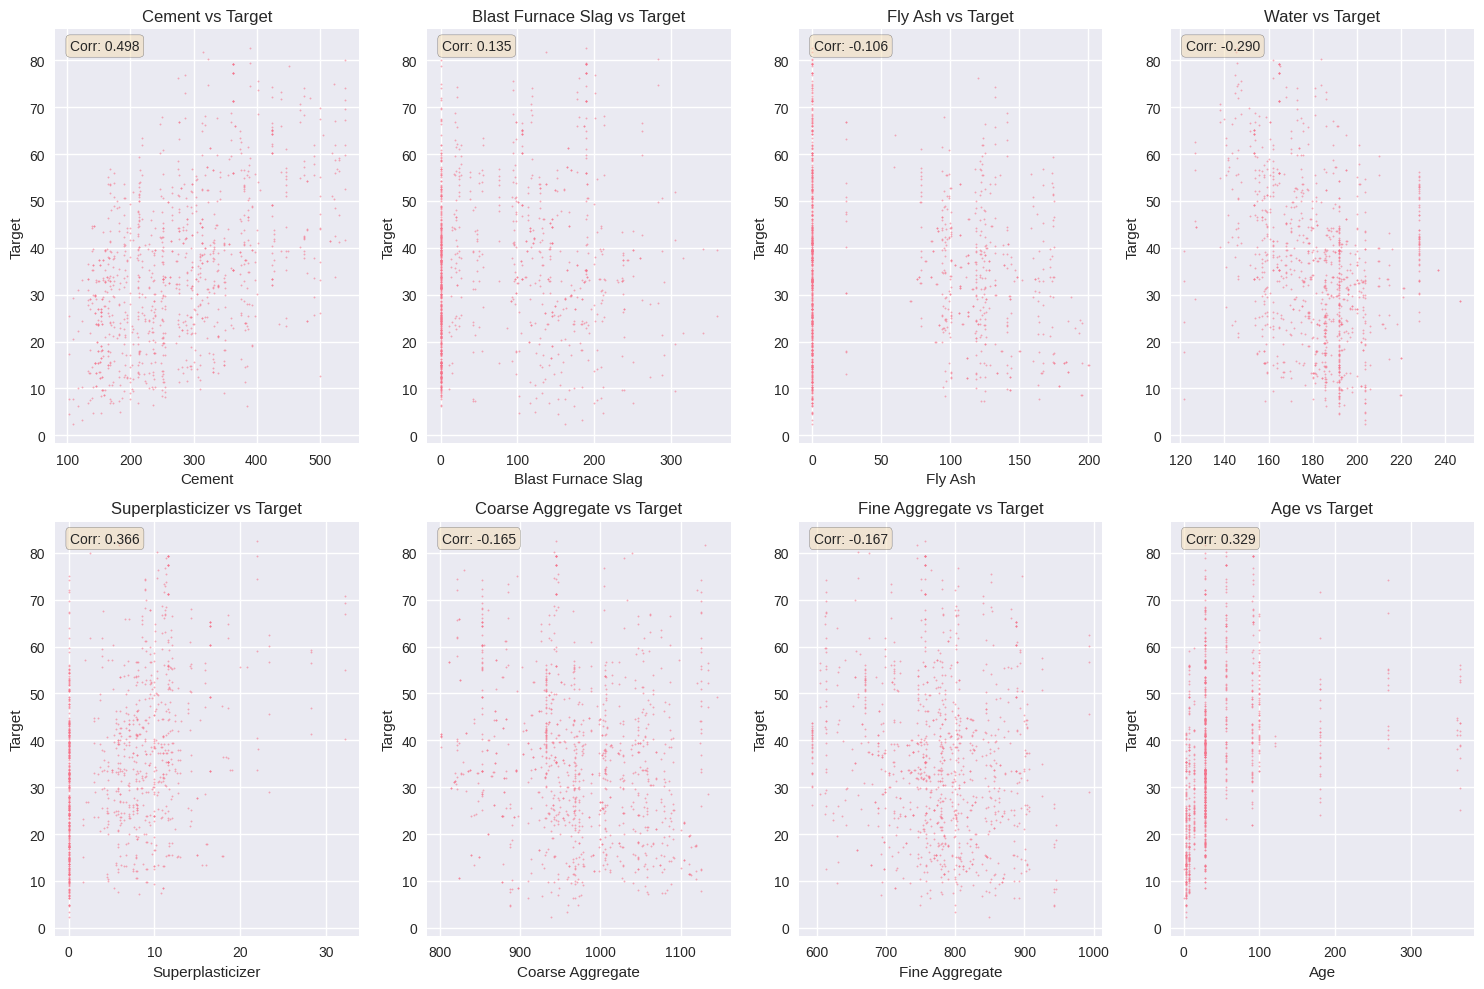

In [29]:
# Já separamos nossas variáveis, mas vamos confirmar e visualizar a relação
print("=== FEATURES (X) ===")
print(f"Formato das features: {X.shape}")
print(f"Nomes das features: {list(X.columns)}")
print(f"Tipos das features: {X.dtypes.unique()}")

print("\n=== TARGET (y) ===")
print(f"Formato do target: {y.shape}")
print(f"Tipo do target: {type(y)}")
print(f"Target é o que queremos prever: Preços das casas")

# Vamos ver a correlação entre features e target
plt.figure(figsize=(15, 10))
n_features = len(X.columns)
n_cols = 4
n_rows = -(-n_features // n_cols)  # arredonda pra cima

for i, column in enumerate(X.columns):
    plt.subplot(n_rows, n_cols, i+1)
    plt.scatter(X[column], y, alpha=0.5, s=1)
    plt.xlabel(column)
    plt.ylabel('Target')
    plt.title(f'{column} vs Target')

    correlation = X[column].corr(pd.Series(y))
    plt.text(0.05, 0.95, f'Corr: {correlation:.3f}',
             transform=plt.gca().transAxes, bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()


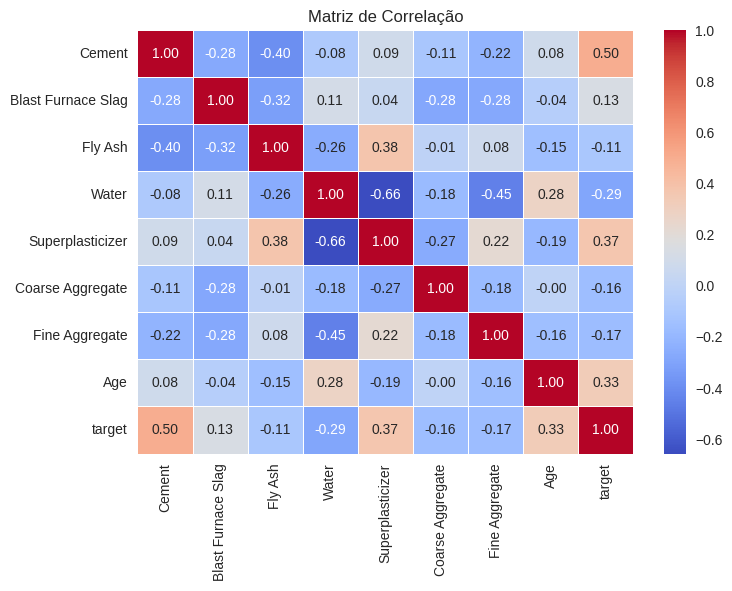

In [30]:
# unimos X e y em um único DataFrame para o cálculo
# Usamos pd.concat para colocar a coluna do target ao lado das outras features
df_para_corr = pd.concat([X, pd.Series(y, name='target')], axis=1)

# matriz de correlação usando o Pandas
matriz_corr = df_para_corr.corr()

# visualizamos com o Seaborn (Heatmap)
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Matriz de Correlação')
plt.show()

In [31]:
# Dividir os dados em conjuntos de treino e teste
# test_size=0.2 significa 20% para teste, 80% para treino
# random_state=42 garante resultados reproduzíveis (mesma divisão sempre)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("=== RESULTADOS DA DIVISÃO DOS DADOS ===")
print(f"Tamanho do dataset original: {X.shape[0]} amostras")
print(f"Tamanho do conjunto de treino: {X_train.shape[0]} amostras ({X_train.shape[0]/X.shape[0]*100:.1f}%)")
print(f"Tamanho do conjunto de teste: {X_test.shape[0]} amostras ({X_test.shape[0]/X.shape[0]*100:.1f}%)")

print(f"\nFormato das features de treino: {X_train.shape}")
print(f"Formato do target de treino: {y_train.shape}")
print(f"Formato das features de teste: {X_test.shape}")
print(f"Formato do target de teste: {y_test.shape}")

print(f"\nEstatísticas do target do conjunto de treino:")
print(f"Média: {y_train.mean():.2f} MPa, Desvio: {y_train.std():.2f} MPa")
print(f"Estatísticas do target do conjunto de teste:")
print(f"Média: {y_test.mean():.2f} MPa, Desvio: {y_test.std():.2f} MPa")
print("✓ Ambos conjuntos têm distribuições similares - boa divisão!")


=== RESULTADOS DA DIVISÃO DOS DADOS ===
Tamanho do dataset original: 1030 amostras
Tamanho do conjunto de treino: 824 amostras (80.0%)
Tamanho do conjunto de teste: 206 amostras (20.0%)

Formato das features de treino: (824, 8)
Formato do target de treino: (824,)
Formato das features de teste: (206, 8)
Formato do target de teste: (206,)

Estatísticas do target do conjunto de treino:
Média: 35.86 MPa, Desvio: 16.87 MPa
Estatísticas do target do conjunto de teste:
Média: 35.66 MPa, Desvio: 16.09 MPa
✓ Ambos conjuntos têm distribuições similares - boa divisão!


In [32]:
# Antes do escalonamento - vamos ver as distribuições originais das features
print("=== ANTES DO ESCALONAMENTO ===")
print("Estatísticas das features do conjunto de treino:")
print(X_train.describe())

# Criar uma instância do StandardScaler
scaler = StandardScaler()

# IMPORTANTE: Ajustar o scaler APENAS nos dados de treino
# Isso previne vazamento de dados do conjunto de teste
scaler.fit(X_train)

# Transformar ambos os conjuntos (treino e teste) usando o scaler ajustado
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Converter de volta para DataFrame para manipulação mais fácil
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("\n=== APÓS O ESCALONAMENTO ===")
print("Estatísticas das features escalonadas do conjunto de treino:")
print(X_train_scaled.describe())

print(f"\n✓ Todas as features agora têm média ≈ 0 e desvio ≈ 1")
print(f"✓ Scaler foi ajustado apenas nos dados de treino")
print(f"✓ Mesma transformação aplicada em ambos os conjuntos (treino e teste)")


=== ANTES DO ESCALONAMENTO ===
Estatísticas das features do conjunto de treino:
           Cement  Blast Furnace Slag     Fly Ash       Water  \
count  824.000000          824.000000  824.000000  824.000000   
mean   283.360801           74.371602   53.160801  181.797087   
std    107.536404           86.977784   64.000646   21.321905   
min    102.000000            0.000000    0.000000  121.800000   
25%    192.000000            0.000000    0.000000  164.900000   
50%    275.100000           22.000000    0.000000  185.350000   
75%    359.900000          144.775000  118.300000  192.000000   
max    540.000000          359.400000  195.000000  247.000000   

       Superplasticizer  Coarse Aggregate  Fine Aggregate         Age  
count        824.000000        824.000000      824.000000  824.000000  
mean           6.163956        973.548544      772.107403   44.661408  
std            5.967258         78.694630       80.984717   60.475702  
min            0.000000        801.000000     

In [33]:
# Criar um modelo de Regressão Linear
model = LinearRegression()

print("=== TREINAMENTO DO MODELO ===")
print(f"Modelo criado: {model}")
print(f"Treinando com {X_train_scaled.shape[0]} amostras e {X_train_scaled.shape[1]} features")

# Treinar o modelo com nossos dados de treino escalonados
# É aqui que o modelo aprende a relação entre features e target
model.fit(X_train_scaled, y_train)

print("✓ Treinamento do modelo concluído!")

# Vamos examinar o que o modelo aprendeu
print(f"\n=== PARÂMETROS DO MODELO ===")
print(f"Intercepto (β₀): {model.intercept_:.4f}")
print(f"Coeficientes (β₁...βₙ):")

# Exibir coeficientes para cada feature
for feature, coef in zip(X_train_scaled.columns, model.coef_):
    print(f"  {feature}: {coef:.4f}")

print(f"\n=== INTERPRETAÇÃO ===")
print("A equação do modelo é:")
equation = f"{nome_target} = {model.intercept_:.4f}"
for feature, coef in zip(X_train_scaled.columns, model.coef_):
    sign = "+" if coef >= 0 else ""
    equation += f" {sign}{coef:.4f}*{feature}"
print(equation)

=== TREINAMENTO DO MODELO ===
Modelo criado: LinearRegression()
Treinando com 824 amostras e 8 features
✓ Treinamento do modelo concluído!

=== PARÂMETROS DO MODELO ===
Intercepto (β₀): 35.8579
Coeficientes (β₁...βₙ):
  Cement: 12.7884
  Blast Furnace Slag: 9.4345
  Fly Ash: 5.2546
  Water: -2.8826
  Superplasticizer: 1.8521
  Coarse Aggregate: 1.4052
  Fine Aggregate: 1.9505
  Age: 7.0374

=== INTERPRETAÇÃO ===
A equação do modelo é:
Resistência do concreto = 35.8579 +12.7884*Cement +9.4345*Blast Furnace Slag +5.2546*Fly Ash -2.8826*Water +1.8521*Superplasticizer +1.4052*Coarse Aggregate +1.9505*Fine Aggregate +7.0374*Age


In [34]:
# Fazer predições nos conjuntos de treino e teste
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

print("=== PREDIÇÕES REALIZADAS ===")
print(f"Formato das predições de treino: {y_train_pred.shape}")
print(f"Formato das predições de teste: {y_test_pred.shape}")

# Vamos ver alguns exemplos de predições vs valores reais
print(f"\n=== PREDIÇÕES EXEMPLO (Primeiras 10 amostras de teste) ===")
comparison_df = pd.DataFrame({
    'Real': y_test[:10],
    'Predito': y_test_pred[:10],
    'Diferença': y_test[:10] - y_test_pred[:10]
})
print(comparison_df)

print(f"\n=== ESTATÍSTICAS DAS PREDIÇÕES ===")
print(f"Conjunto de treino:")
print(f"  Média real: {y_train.mean():.2f} MPa")
print(f"  Média predita: {y_train_pred.mean():.2f} MPa")
print(f"Conjunto de teste:")
print(f"  Média real: {y_test.mean():.2f} MPa")
print(f"  Média predita: {y_test_pred.mean():.2f} MPa")


=== PREDIÇÕES REALIZADAS ===
Formato das predições de treino: (824,)
Formato das predições de teste: (206,)

=== PREDIÇÕES EXEMPLO (Primeiras 10 amostras de teste) ===
       Real    Predito  Diferença
31    52.91  59.658042  -6.748042
109   55.90  52.041211   3.858789
136   74.50  63.535133  10.964867
88    35.30  51.575457 -16.275457
918   10.54  17.220017  -6.680017
1025  44.28  39.865613   4.414387
870   23.69  26.698247  -3.008247
318   45.37  44.736489   0.633511
261   37.40  29.366198   8.033802
535   48.85  38.186125  10.663875

=== ESTATÍSTICAS DAS PREDIÇÕES ===
Conjunto de treino:
  Média real: 35.86 MPa
  Média predita: 35.86 MPa
Conjunto de teste:
  Média real: 35.66 MPa
  Média predita: 35.64 MPa


In [35]:
def evaluate_model(y_true, y_pred, dataset_name):
    """Calcular e exibir métricas de avaliação do modelo"""
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)

    print(f"=== AVALIAÇÃO DO CONJUNTO {dataset_name.upper()} ===")
    print(f"Score R²: {r2:.4f} ({r2*100:.2f}% da variância explicada)")
    print(f"Erro Quadrático Médio: {mse:.4f}")
    print(f"Raiz do Erro Quadrático Médio: {rmse:.4f} {unidade_target}")
    print(f"Erro Absoluto Médio: {mae:.4f} {unidade_target}")

    return r2, mse, rmse, mae

train_r2, train_mse, train_rmse, train_mae = evaluate_model(y_train, y_train_pred, "treino")
print()
test_r2, test_mse, test_rmse, test_mae = evaluate_model(y_test, y_test_pred, "teste")

print(f"\n=== RESUMO DA PERFORMANCE DO MODELO ===")
print(f"R² Treino: {train_r2:.4f} | R² Teste: {test_r2:.4f}")
print(f"RMSE Treino: {train_rmse:.4f} | RMSE Teste: {test_rmse:.4f}")

if train_r2 - test_r2 > 0.1:
    print("⚠️  Possível overfitting detectado (R² treino >> R² teste)")
elif abs(train_r2 - test_r2) < 0.05:
    print("✓ Boa generalização (performance similar em treino/teste)")
else:
    print("✓ Modelo parece generalizar bem")

=== AVALIAÇÃO DO CONJUNTO TREINO ===
Score R²: 0.6105 (61.05% da variância explicada)
Erro Quadrático Médio: 110.6449
Raiz do Erro Quadrático Médio: 10.5188 MPa
Erro Absoluto Médio: 8.3301 MPa

=== AVALIAÇÃO DO CONJUNTO TESTE ===
Score R²: 0.6276 (62.76% da variância explicada)
Erro Quadrático Médio: 95.9709
Raiz do Erro Quadrático Médio: 9.7965 MPa
Erro Absoluto Médio: 7.7456 MPa

=== RESUMO DA PERFORMANCE DO MODELO ===
R² Treino: 0.6105 | R² Teste: 0.6276
RMSE Treino: 10.5188 | RMSE Teste: 9.7965
✓ Boa generalização (performance similar em treino/teste)


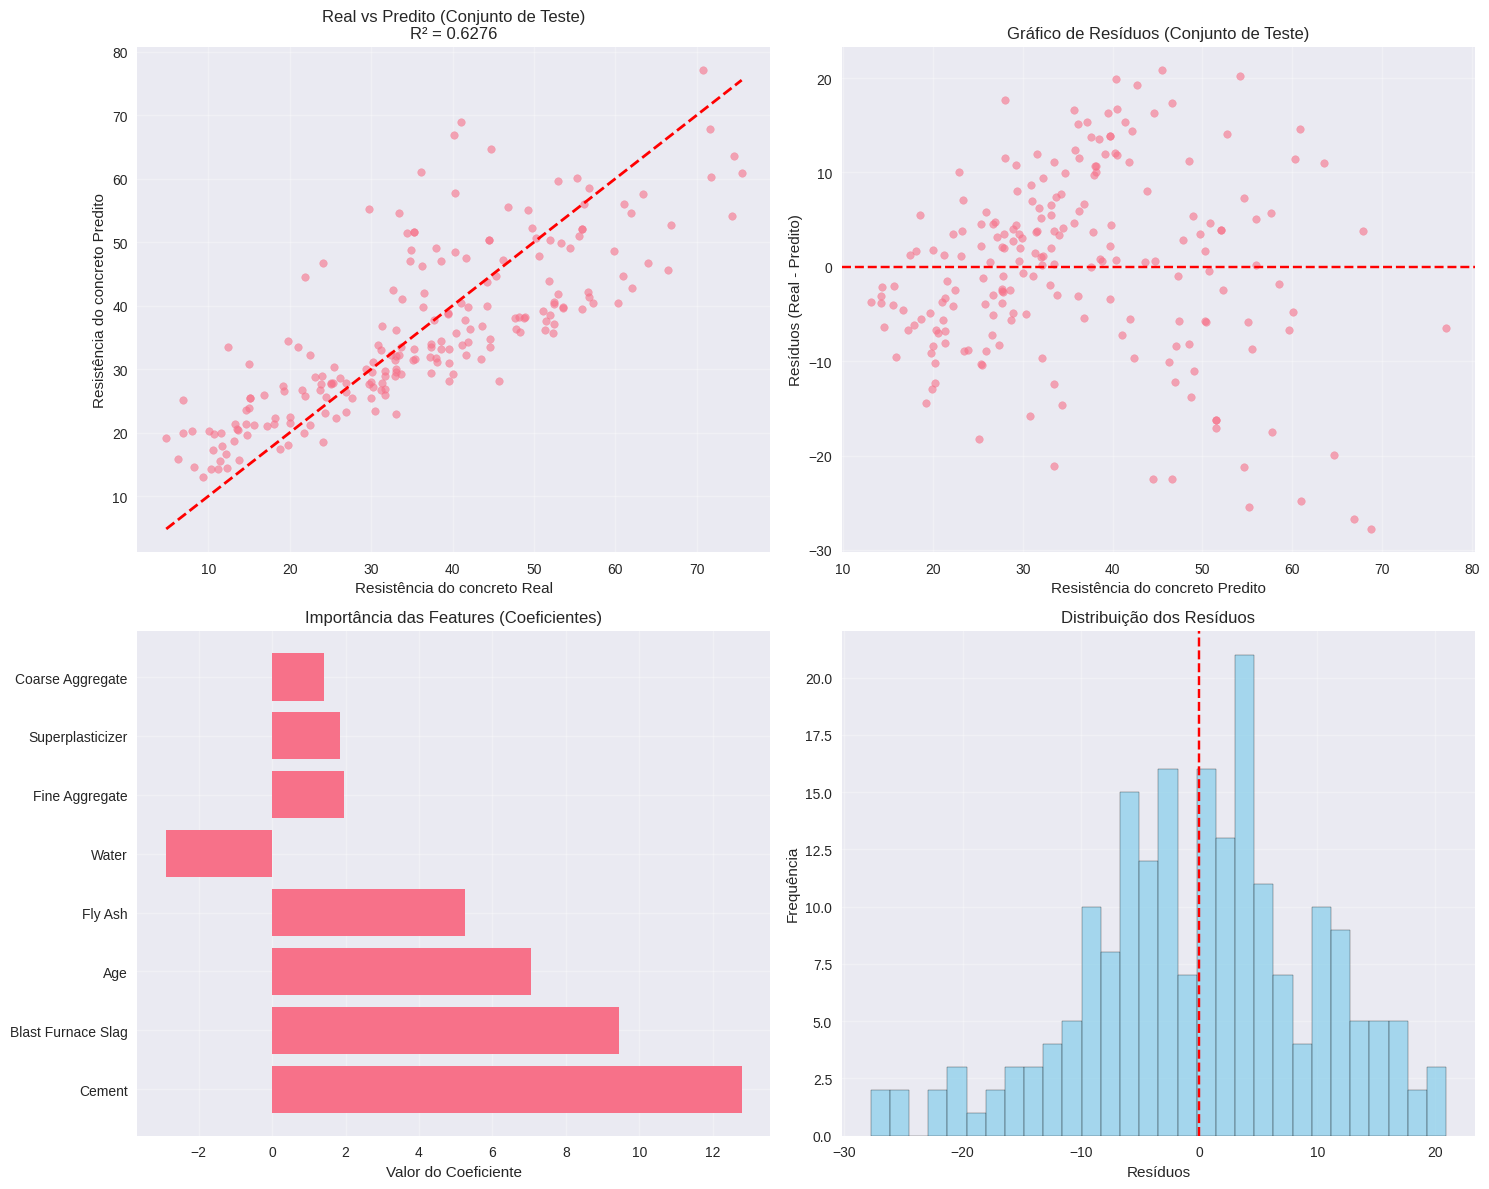

=== INTERPRETAÇÃO DAS VISUALIZAÇÕES ===
1. Real vs Predito: Pontos próximos à linha vermelha indicam boas predições
2. Gráfico de Resíduos: Pontos aleatoriamente espalhados ao redor do zero indicam bom ajuste do modelo
3. Importância das Features: Mostra quais features têm a influência mais forte
4. Distribuição dos Resíduos: Deve ser aproximadamente normal (forma de sino) ao redor do zero


In [36]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Real vs Predito (Conjunto de Teste)
axes[0, 0].scatter(y_test, y_test_pred, alpha=0.6, s=30)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel(f'{nome_target} Real')
axes[0, 0].set_ylabel(f'{nome_target} Predito')
axes[0, 0].set_title(f'Real vs Predito (Conjunto de Teste)\nR² = {test_r2:.4f}')
axes[0, 0].grid(True, alpha=0.3)

# 2. Gráfico de Resíduos (Conjunto de Teste)
residuals = y_test - y_test_pred
axes[0, 1].scatter(y_test_pred, residuals, alpha=0.6, s=30)
axes[0, 1].axhline(y=0, color='r', linestyle='--')
axes[0, 1].set_xlabel(f'{nome_target} Predito')
axes[0, 1].set_ylabel('Resíduos (Real - Predito)')
axes[0, 1].set_title('Gráfico de Resíduos (Conjunto de Teste)')
axes[0, 1].grid(True, alpha=0.3)

# 3. Importância das Features (Coeficientes)
feature_importance = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': model.coef_
})
feature_importance = feature_importance.sort_values('Coefficient', key=abs, ascending=False)

axes[1, 0].barh(feature_importance['Feature'], feature_importance['Coefficient'])
axes[1, 0].set_xlabel('Valor do Coeficiente')
axes[1, 0].set_title('Importância das Features (Coeficientes)')
axes[1, 0].grid(True, alpha=0.3)

# 4. Distribuição dos Resíduos
axes[1, 1].hist(residuals, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
axes[1, 1].axvline(x=0, color='r', linestyle='--')
axes[1, 1].set_xlabel('Resíduos')
axes[1, 1].set_ylabel('Frequência')
axes[1, 1].set_title('Distribuição dos Resíduos')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("=== INTERPRETAÇÃO DAS VISUALIZAÇÕES ===")
print("1. Real vs Predito: Pontos próximos à linha vermelha indicam boas predições")
print("2. Gráfico de Resíduos: Pontos aleatoriamente espalhados ao redor do zero indicam bom ajuste do modelo")
print("3. Importância das Features: Mostra quais features têm a influência mais forte")
print("4. Distribuição dos Resíduos: Deve ser aproximadamente normal (forma de sino) ao redor do zero")

In [37]:
# Insights adicionais: Análise das features
print("=== ANÁLISE DETALHADA DAS FEATURES ===")
print("\nFeatures mais importantes (por valor absoluto do coeficiente):")
for i, row in feature_importance.head(3).iterrows():
    coef_value = row['Coefficient']
    feature_name = row['Feature']
    direction = "aumenta" if coef_value > 0 else "diminui"
    print(f"• {feature_name}: {abs(coef_value):.4f} - {nome_target} {direction} quando esta feature aumenta")

print(f"\nResumo da Performance do Modelo:")
print(f"• O modelo explica {test_r2*100:.1f}% da variância em {nome_target}")
print(f"• Erro médio de predição: {test_mae:.2f} {unidade_target}")
print(f"• Modelo pode prever {nome_target} dentro de ±{test_rmse:.2f} {unidade_target} em média")

print(f"\n=== EXEMPLO DE PREDIÇÃO ===")
sample_features = X_test_scaled.iloc[0:1]
sample_actual = y_test.iloc[0]
sample_prediction = model.predict(sample_features)[0]

print(f"Features da amostra (padronizadas):")
for feature, value in zip(sample_features.columns, sample_features.iloc[0]):
    print(f"  {feature}: {value:.2f}")
print(f"\n{nome_target} real: {sample_actual:.2f} {unidade_target}")
print(f"{nome_target} predito: {sample_prediction:.2f} {unidade_target}")
print(f"Erro de predição: {abs(sample_actual - sample_prediction):.2f} {unidade_target}")

=== ANÁLISE DETALHADA DAS FEATURES ===

Features mais importantes (por valor absoluto do coeficiente):
• Cement: 12.7884 - Resistência do concreto aumenta quando esta feature aumenta
• Blast Furnace Slag: 9.4345 - Resistência do concreto aumenta quando esta feature aumenta
• Age: 7.0374 - Resistência do concreto aumenta quando esta feature aumenta

Resumo da Performance do Modelo:
• O modelo explica 62.8% da variância em Resistência do concreto
• Erro médio de predição: 7.75 MPa
• Modelo pode prever Resistência do concreto dentro de ±9.80 MPa em média

=== EXEMPLO DE PREDIÇÃO ===
Features da amostra (padronizadas):
  Cement: -0.16
  Blast Furnace Slag: 0.46
  Fly Ash: -0.83
  Water: 2.17
  Superplasticizer: -1.03
  Coarse Aggregate: -0.53
  Fine Aggregate: -1.26
  Age: 5.30

Resistência do concreto real: 52.91 MPa
Resistência do concreto predito: 59.66 MPa
Erro de predição: 6.75 MPa
